# Solving the Traveling Salesman Problem: A Comparative Analysis of Hill Climbing and Genetic Algorithm Optimisation

**Module:** UFCEL1-15-M — AI for Search and Optimisation
**Assessment:** Resit — Practical Skills Assessment (Portfolio)
**Student Name:** Keith Goatley
**Student Number:** 25043830

---

## Project Overview
This notebook implements and compares two approaches to solving the Traveling Salesman Problem (TSP) on a 50 city instance: a single-solution local search algorithm and a population-based Evolutionary Algorithm. Performance is evaluated across solution quality, convergence speed, computational efficiency, and scalability.

## Data Loading and Exploration

My first section loads the `cities.csv` file, which contains 50 cities defined by X and Y coordinates. Visualising the raw city layout provides context for interpreting the routes generated by each algorithm later in this notebook.

Number of cities loaded: 50


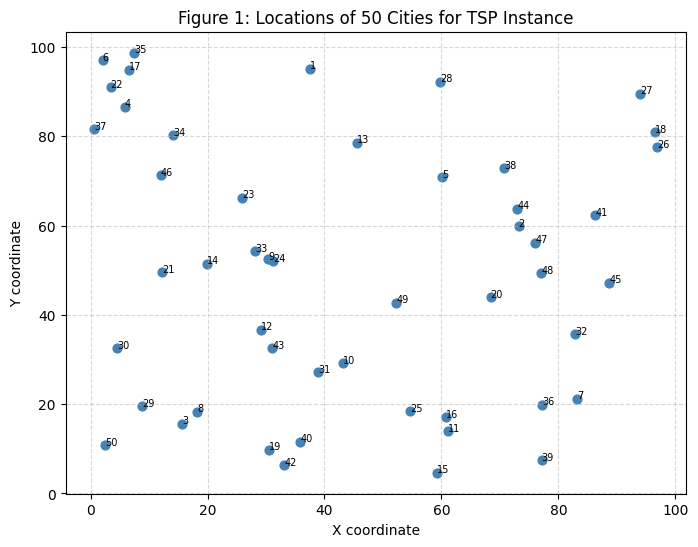

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

def load_cities(filepath):
    """
    Load city coordinates from a CSV file into a DataFrame.

    Args:
        filepath (str): Path to the cities CSV file.

    Returns:
        pd.DataFrame: DataFrame with columns City, X, Y.

    Raises:
        FileNotFoundError: If the file does not exist at the given path.
        ValueError: If the file is empty or missing required columns.
    """
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"Could not find '{filepath}'. Ensure cities.csv is in the same "
            f"directory as this notebook."
        )
    except pd.errors.EmptyDataError:
        raise ValueError(f"The file '{filepath}' is empty.")

    required = {'City', 'X', 'Y'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(
            f"'{filepath}' is missing required column(s): {sorted(missing)}."
        )
    if df.empty:
        raise ValueError(f"'{filepath}' contains no city records.")

    return df

def plot_cities(df, title="City Locations"):
    """
    Plot city locations as a scatter plot.

    Args:
        df (pd.DataFrame): DataFrame containing X and Y coordinates.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(df['X'], df['Y'], c='steelblue', s=40)
    for _, row in df.iterrows():
        plt.annotate(row['City'].replace('City_', ''), (row['X'], row['Y']), fontsize=7)
    plt.title(title)
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

cities_df = load_cities('cities.csv')
print(f"Number of cities loaded: {len(cities_df)}")
plot_cities(cities_df, title="Figure 1: Locations of 50 Cities for TSP Instance")

### Reproducibility and Search Parameters

Both algorithms use randomness, so I'll set fixed random seeds to make results reproducible.

In [38]:
SEED = 42

HC_MAX_ITERATIONS = 20000
HC_STALL_LIMIT = 2000

GA_POP_SIZE = 100
GA_GENERATIONS = 500
GA_MUTATION_RATE = 0.02
GA_TOURNAMENT_K = 5


def set_seed(seed=SEED):
    """Set the random seed for Python's random module and NumPy."""
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

## Distance Calculation

Both algorithms require a way to calculate the total distance of a route. This section will define a distance function between two cities and a function to compute the total tour distance, including the return to the starting city.

In [42]:
import numpy as np


def euclidean_distance(city1, city2):
    """
    Calculate Euclidean distance between two cities.

    Args:
        city1 (tuple): (x, y) coordinates of first city.
        city2 (tuple): (x, y) coordinates of second city.

    Returns:
        float: Euclidean distance between the two points.
    """
    return np.sqrt((city1[0] - city2[0])**2 + (city1[1] - city2[1])**2)


def total_distance(route, coords):
    """
    Calculate total distance of a tour, including return to start.

    Args:
        route (list): Ordered list of city indices representing the tour.
        coords (list): List of (x, y) tuples for each city, indexed to
            match route.

    Returns:
        float: Total distance of the closed tour.

    Raises:
        ValueError: If the route contains fewer than two cities.
    """
    if len(route) < 2:
        raise ValueError("A tour must contain at least two cities.")

    dist = 0.0
    for i in range(len(route)):
        current_city = coords[route[i]]
        next_city = coords[route[(i + 1) % len(route)]]
        dist += euclidean_distance(current_city, next_city)
    return dist


coords = list(zip(cities_df['X'], cities_df['Y']))
sample_route = list(range(len(coords)))
print(f"Distance of unoptimised route (0,1,2,...,49): "
      f"{total_distance(sample_route, coords):.2f}")

Distance of unoptimised route (0,1,2,...,49): 2663.96


### Hill Climbing (Random Restart)

I chose random restart hill climbing over the two alternative single-solution algorithms for a few reasons. Simulated annealing can also escape local optima by accepting worse moves, but the performance is sensitive to the cooling schedule.

Tabu search avoids revisiting recent solutions using a memory structure, but it introduces overhead and further hyperparameters that require tuning.

Random restarts achieve the same goal with a single hyperparameter, whcih makes its exploration exploitation easy to control and analyse. Repeated restarts also sampe the search space more boradly, giving a more complete view.

In [40]:
import random

def get_neighbour(route):
    """
    Generate a neighbouring solution by swapping two random cities.

    Args:
        route (list): Current route (list of city indices).

    Returns:
        list: New route with two cities swapped.
    """
    new_route = route.copy()
    i, j = random.sample(range(len(route)), 2)
    new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route

def hill_climb(coords, max_iterations=1000, stall_limit=100):
    """
    Random Restart Hill Climbing algorithm for TSP.

    Args:
        coords (list): List of (x, y) tuples for each city.
        max_iterations (int): Maximum total iterations across all restarts.
        stall_limit (int): Iterations without improvement before a random restart.

    Returns:
        tuple: (best_route, best_distance, history) where history logs
               best distance at each iteration for convergence plotting.
    """
    n = len(coords)
    current_route = list(range(n))
    random.shuffle(current_route)
    current_dist = total_distance(current_route, coords)

    best_route, best_dist = current_route, current_dist
    history = [best_dist]
    stall_counter = 0

    for _ in range(max_iterations):
        neighbour = get_neighbour(current_route)
        neighbour_dist = total_distance(neighbour, coords)

        if neighbour_dist < current_dist:
            current_route, current_dist = neighbour, neighbour_dist
            stall_counter = 0
        else:
            stall_counter += 1

        if current_dist < best_dist:
            best_route, best_dist = current_route, current_dist

        if stall_counter >= stall_limit:
            current_route = list(range(n))
            random.shuffle(current_route)
            current_dist = total_distance(current_route, coords)
            stall_counter = 0

        history.append(best_dist)

    return best_route, best_dist, history

set_seed(SEED)
best_route, best_dist, history = hill_climb(
    coords, max_iterations=HC_MAX_ITERATIONS, stall_limit=HC_STALL_LIMIT
)
swap_route, swap_dist, swap_history = best_route, best_dist, history
print(f"Best distance found by baseline Hill Climbing (swap): {best_dist:.2f}")

Best distance found by baseline Hill Climbing (swap): 793.32




### Hill Climbing Results

Figure 2 shows the optimized routes found by the random restart hill climber using the swap neighbourhood.

Figure 3 shows its convergence. The best difference falls in the first few thousand iterations and then improves slowly. The resulting route contains several crossing edges. This indicates the swap neighbourhood is not powerful enough to remove them.

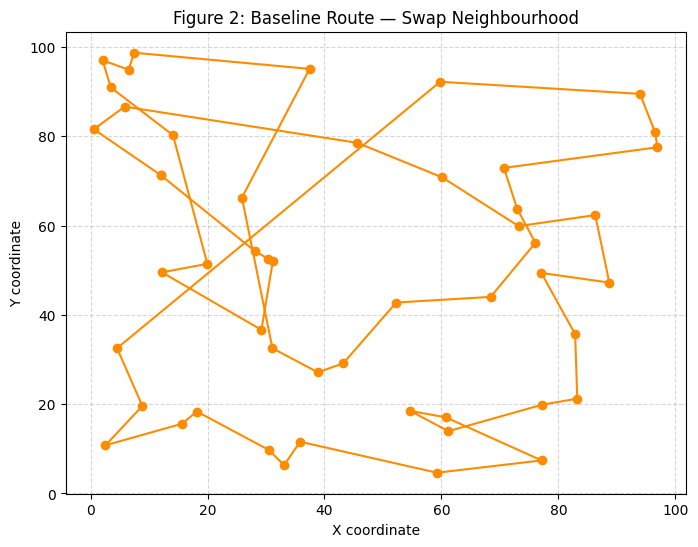

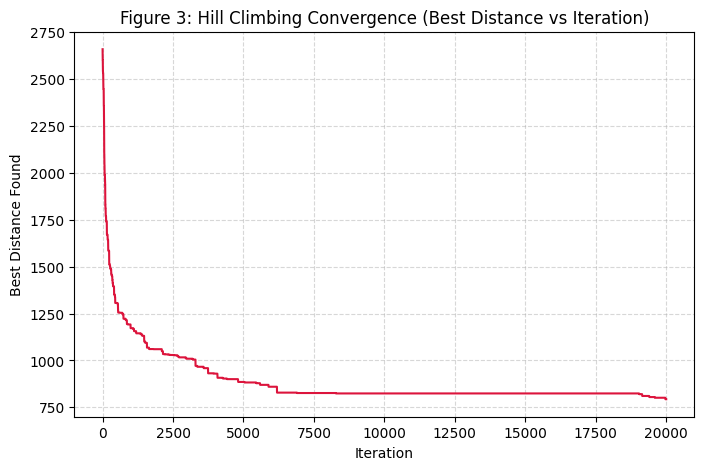

In [23]:
def plot_route(route, coords, title="Optimised Route"):
    """
    Plot a TSP route connecting cities in order, returning to start.

    Args:
        route (list): Ordered list of city indices.
        coords (list): List of (x, y) tuples for each city.
        title (str): Title for the plot.
    """
    ordered_coords = [coords[i] for i in route] + [coords[route[0]]]
    xs, ys = zip(*ordered_coords)
    plt.figure(figsize=(8, 6))
    plt.plot(xs, ys, 'o-', color='darkorange')
    plt.title(title)
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


plot_route(best_route, coords, title="Figure 2: Baseline Route — Swap Neighbourhood")


plt.figure(figsize=(8, 5))
plt.plot(history, color='crimson')
plt.title("Figure 3: Hill Climbing Convergence (Best Distance vs Iteration)")
plt.xlabel("Iteration")
plt.ylabel("Best Distance Found")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Revised Hill Climbing with 2-opt Neighbourhood

The initial swap-based neighbourhood gave a route with multiple self-crossings, indicating a weak local search. I revised it to use a 2-opt move. Two edges in the route are selected and the segment between them is reversed. It directly removes crossing edges and produces a stronger, more exploitative search than simple swaps.

In [24]:
def two_opt_neighbour(route):
    """
    Generate a neighbouring solution using a 2-opt move.

    Selects two positions in the route and reverses the segment
    between them, which removes crossing edges.

    Args:
        route (list): Current route (list of city indices).

    Returns:
        list: New route with a segment reversed.
    """
    new_route = route.copy()
    i, j = sorted(random.sample(range(len(route)), 2))
    new_route[i:j+1] = reversed(new_route[i:j+1])
    return new_route

def hill_climb_2opt(coords, max_iterations=20000, stall_limit=2000):
    """
    Random Restart Hill Climbing with 2-opt neighbourhood for TSP.

    Args:
        coords (list): List of (x, y) tuples for each city.
        max_iterations (int): Maximum total iterations across all restarts.
        stall_limit (int): Iterations without improvement before a random restart.

    Returns:
        tuple: (best_route, best_distance, history)
    """
    n = len(coords)
    current_route = list(range(n))
    random.shuffle(current_route)
    current_dist = total_distance(current_route, coords)

    best_route, best_dist = current_route, current_dist
    history = [best_dist]
    stall_counter = 0

    for _ in range(max_iterations):
        neighbour = two_opt_neighbour(current_route)
        neighbour_dist = total_distance(neighbour, coords)

        if neighbour_dist < current_dist:
            current_route, current_dist = neighbour, neighbour_dist
            stall_counter = 0
        else:
            stall_counter += 1

        if current_dist < best_dist:
            best_route, best_dist = current_route, current_dist

        if stall_counter >= stall_limit:
            current_route = list(range(n))
            random.shuffle(current_route)
            current_dist = total_distance(current_route, coords)
            stall_counter = 0

        history.append(best_dist)

    return best_route, best_dist, history

set_seed(SEED)
best_route, best_dist, history = hill_climb_2opt(
    coords, max_iterations=HC_MAX_ITERATIONS, stall_limit=HC_STALL_LIMIT
)
improvement = 100 * (swap_dist - best_dist) / swap_dist
print(f"Best distance found by Hill Climbing (2-opt): {best_dist:.2f}")
print(f"Improvement over swap neighbourhood: {improvement:.1f}%")

Best distance found by Hill Climbing (2-opt): 603.59
Improvement over swap neighbourhood: 23.9%


### 2-opt Results

The refined route in Figure four contains no crossings. This confirms that the 2-opt move successfully removes the crossing edges in the swap neighbourhood left behind.

Figure 5 compares convergence under an identical iteration. The 2-opt search reaches a substantially better solution than the swap neighbourhood.

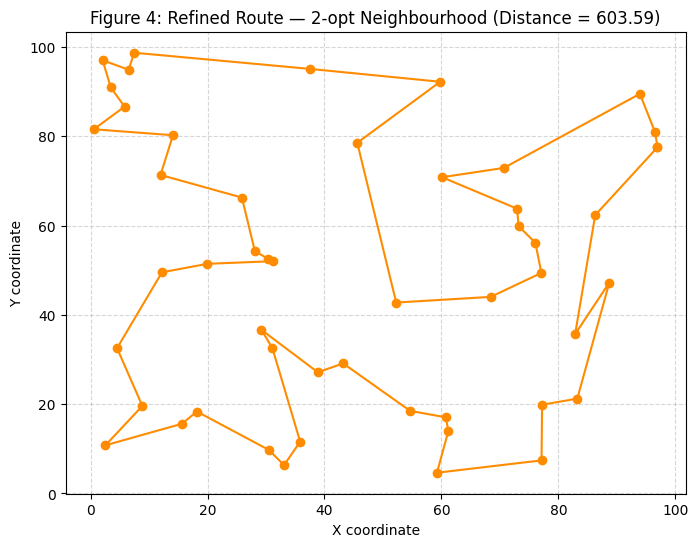

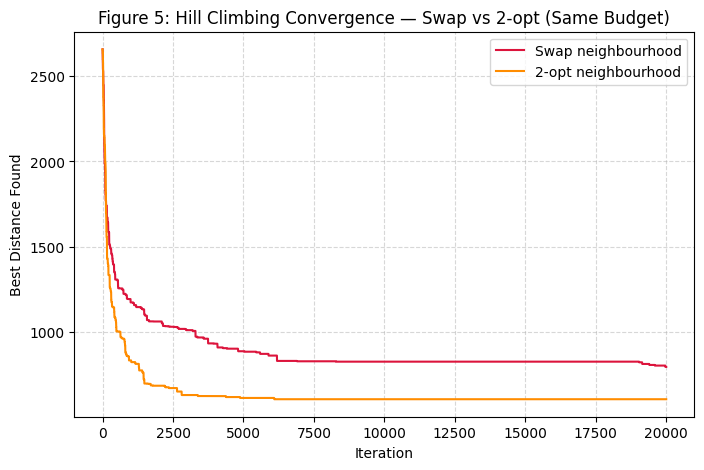

In [25]:
plot_route(best_route, coords,
           title=f"Figure 4: Refined Route — 2-opt Neighbourhood (Distance = {best_dist:.2f})")

plt.figure(figsize=(8, 5))
plt.plot(swap_history, color='crimson', label='Swap neighbourhood')
plt.plot(history, color='darkorange', label='2-opt neighbourhood')
plt.title("Figure 5: Hill Climbing Convergence — Swap vs 2-opt (Same Budget)")
plt.xlabel("Iteration")
plt.ylabel("Best Distance Found")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Hill Climbing Hyperparameter Tuning

The key hyperparameter is the **stall limit**. It controls exploration vs exploitation. I'll sweep four values with three independent seeded runs each and select the lowest mean best distance.

 StallLimit   mean   std
        500 599.91 14.53
       1000 592.72 18.65
       2000 588.45 15.26
       4000 592.02 14.07

Selected stall limit: 2000


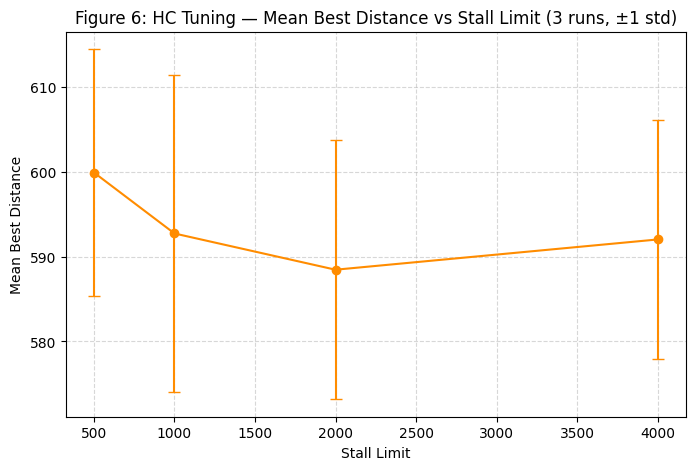

In [26]:
stall_limits = [500, 1000, 2000, 4000]
hc_tuning_rows = []

for stall in stall_limits:
    for rep in range(3):
        set_seed(SEED + rep)
        _, dist, _ = hill_climb_2opt(coords, max_iterations=HC_MAX_ITERATIONS,
                                     stall_limit=stall)
        hc_tuning_rows.append({'StallLimit': stall, 'Rep': rep, 'Distance': dist})

hc_tuning_df = pd.DataFrame(hc_tuning_rows)
hc_summary = hc_tuning_df.groupby('StallLimit')['Distance'].agg(['mean', 'std']).reset_index()
print(hc_summary.round(2).to_string(index=False))

HC_STALL_LIMIT_TUNED = int(hc_summary.loc[hc_summary['mean'].idxmin(), 'StallLimit'])
print(f"\nSelected stall limit: {HC_STALL_LIMIT_TUNED}")

plt.figure(figsize=(8, 5))
plt.errorbar(hc_summary['StallLimit'], hc_summary['mean'], yerr=hc_summary['std'],
             fmt='o-', color='darkorange', capsize=4)
plt.title("Figure 6: HC Tuning — Mean Best Distance vs Stall Limit (3 runs, ±1 std)")
plt.xlabel("Stall Limit")
plt.ylabel("Mean Best Distance")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Saving the Best Route

The sequence of cities in the best route found by Hill Climbing is saved to an external file for record-keeping and reproducibility.

In [27]:
set_seed(SEED)
best_route, best_dist, history = hill_climb_2opt(
    coords, max_iterations=HC_MAX_ITERATIONS, stall_limit=HC_STALL_LIMIT_TUNED
)
print(f"Total distance of shortest route (Hill Climbing, tuned): {best_dist:.2f}")

def save_route_to_file(route, cities_df, filename):
    """
    Save the sequence of cities in a route to a text file.

    Args:
        route (list): Ordered list of city indices.
        cities_df (pd.DataFrame): DataFrame containing city names.
        filename (str): Output filename.
    """
    with open(filename, 'w') as f:
        for idx in route:
            f.write(f"{cities_df.iloc[idx]['City']}\n")
        f.write(f"{cities_df.iloc[route[0]]['City']}\n")

save_route_to_file(best_route, cities_df, 'hill_climbing_best_route.txt')
print("Route saved to hill_climbing_best_route.txt")

with open('hill_climbing_best_route.txt') as f:
    print(f.read())

Total distance of shortest route (Hill Climbing, tuned): 603.59
Route saved to hill_climbing_best_route.txt
City_26
City_41
City_32
City_45
City_7
City_36
City_39
City_15
City_11
City_16
City_25
City_10
City_31
City_12
City_43
City_40
City_42
City_19
City_8
City_3
City_50
City_29
City_30
City_21
City_14
City_24
City_9
City_33
City_23
City_46
City_34
City_37
City_4
City_22
City_6
City_17
City_35
City_1
City_28
City_13
City_49
City_20
City_48
City_47
City_2
City_44
City_5
City_38
City_27
City_18
City_26



## Genetic Algorithm (Evolutionary in this case)

This section uses a Genetic Algorithm to solve the same TSP instance, after the select-recombine-mutate-replace framework. The route is shown as a permutation of city indices. Order Crossover is used for recombination, as it preserves valid permutations, and swap mutation introduces diversity. I'll use tournament selection to choose parents, biasing selection toward fitter individuals while retaining some randomness to preserve exploration.

The single-point crossover and roulette-wheel selection covered in the module
lectures are unsuitable for the TSP without modification: single-point crossover
applied to a permutation produces invalid tours containing duplicate and
missing cities, and roulette-wheel selection requires transforming the
minimisation objective (distance) into a maximisable fitness.

Order Crossover guarantees valid permutations by construction, and tournament selection works directly with the raw distance values, so both were chosen in preference to the taught operators.



In [28]:
def create_individual(n):
    """
    Create a random individual (route) as a permutation of city indices.

    Args:
        n (int): Number of cities.

    Returns:
        list: Random permutation of city indices.
    """
    individual = list(range(n))
    random.shuffle(individual)
    return individual

def create_population(pop_size, n):
    """
    Create an initial population of random individuals.

    Args:
        pop_size (int): Number of individuals in the population.
        n (int): Number of cities.

    Returns:
        list: List of individuals (routes).
    """
    return [create_individual(n) for _ in range(pop_size)]

def tournament_selection(population, fitnesses, k=5):
    """
    Select one parent using tournament selection.

    Args:
        population (list): List of individuals.
        fitnesses (list): Corresponding fitness (distance) values.
        k (int): Tournament size.

    Returns:
        list: Selected individual (route).
    """
    participants = random.sample(range(len(population)), k)
    best = min(participants, key=lambda idx: fitnesses[idx])
    return population[best]

pop_size = 100
population = create_population(pop_size, len(coords))
fitnesses = [total_distance(ind, coords) for ind in population]
print(f"Initial population size: {len(population)}")
print(f"Best fitness in initial random population: {min(fitnesses):.2f}")

Initial population size: 100
Best fitness in initial random population: 2203.43


### Crossover, Mutation, and Evolution Loop

Order Crossover (OX) uses two parent routes. Swap mutation randomly exchanges two cities in an individual with a small probability, introducing diversity to avoid premature convergence. The population changes over a fixed number of generations using elitism combined with tournament-selected offspring.

In [29]:
def order_crossover(parent1, parent2):
    """
    Perform Order Crossover (OX) between two parent routes.

    Args:
        parent1 (list): First parent route.
        parent2 (list): Second parent route.

    Returns:
        list: Child route produced by combining both parents.
    """
    size = len(parent1)
    start, end = sorted(random.sample(range(size), 2))
    child = [None] * size
    child[start:end] = parent1[start:end]

    fill_values = [gene for gene in parent2 if gene not in child]
    fill_positions = [i for i in range(size) if child[i] is None]

    for pos, val in zip(fill_positions, fill_values):
        child[pos] = val

    return child

def swap_mutation(individual, mutation_rate=0.02):
    """
    Apply swap mutation to an individual with a given probability per gene.

    Args:
        individual (list): Route to mutate.
        mutation_rate (float): Probability of mutation per city.

    Returns:
        list: Mutated route.
    """
    individual = individual.copy()
    for i in range(len(individual)):
        if random.random() < mutation_rate:
            j = random.randint(0, len(individual) - 1)
            individual[i], individual[j] = individual[j], individual[i]
    return individual

def genetic_algorithm(coords, pop_size=100, generations=500, mutation_rate=0.02, tournament_k=5):
    """
    Run a Genetic Algorithm to solve the TSP.

    Args:
        coords (list): List of (x, y) tuples for each city.
        pop_size (int): Population size.
        generations (int): Number of generations to evolve.
        mutation_rate (float): Probability of mutation per gene.
        tournament_k (int): Tournament selection size.

    Returns:
        tuple: (best_route, best_distance, history)
    """
    n = len(coords)
    population = create_population(pop_size, n)
    fitnesses = [total_distance(ind, coords) for ind in population]

    best_idx = fitnesses.index(min(fitnesses))
    best_individual = population[best_idx]
    best_fitness = fitnesses[best_idx]
    history = [best_fitness]

    for gen in range(generations):
        new_population = [best_individual]

        while len(new_population) < pop_size:
            parent1 = tournament_selection(population, fitnesses, tournament_k)
            parent2 = tournament_selection(population, fitnesses, tournament_k)
            child = order_crossover(parent1, parent2)
            child = swap_mutation(child, mutation_rate)
            new_population.append(child)

        population = new_population
        fitnesses = [total_distance(ind, coords) for ind in population]

        gen_best_idx = fitnesses.index(min(fitnesses))
        if fitnesses[gen_best_idx] < best_fitness:
            best_individual = population[gen_best_idx]
            best_fitness = fitnesses[gen_best_idx]

        history.append(best_fitness)

    return best_individual, best_fitness, history

## Genetic Algorithm Hyperparameter Tuning

I'll tune the two hyperparameters expected to matter most, in two screening stages of 300 generations.

Stage 1 — mutation rate.

Stage 2 — population size.

Stage 1 — mutation rate screening:
 MutationRate    mean   std
         0.00  828.80 55.69
         0.02  774.46 78.11
         0.05 1208.43 57.36
         0.10 1581.54 92.10
Selected mutation rate: 0.02

Stage 2 — population size screening:
 PopSize  Distance  Time
      50    843.87  2.40
     100    774.46  4.52
     200    691.28  9.07
Selected population size: 200


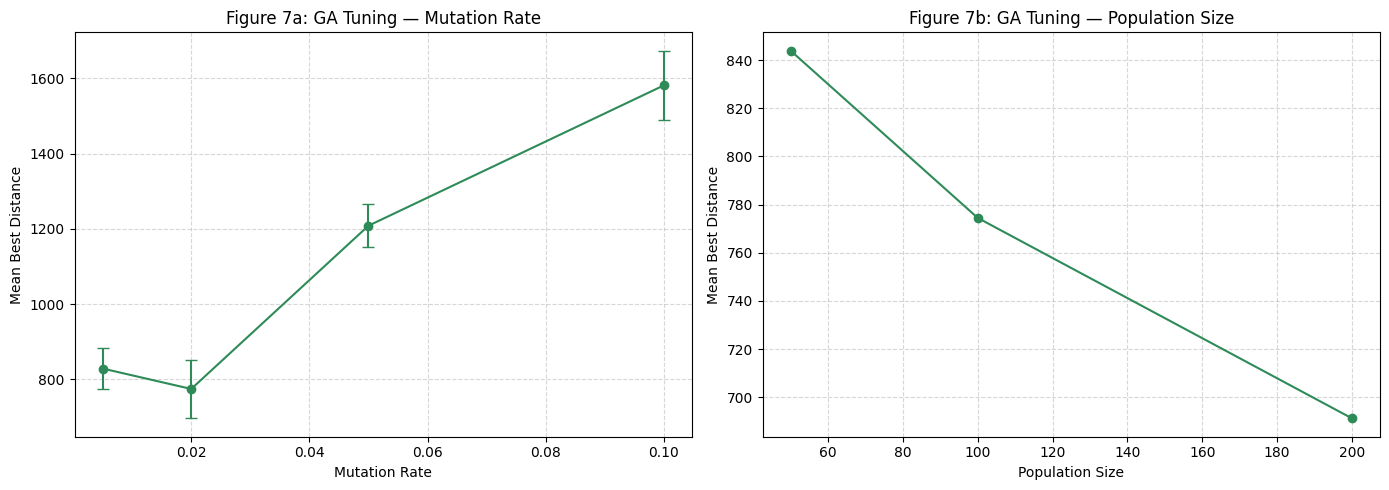

In [30]:
import time

mut_rows = []
for rate in [0.005, 0.02, 0.05, 0.1]:
    for rep in range(3):
        set_seed(SEED + rep)
        _, dist, _ = genetic_algorithm(coords, pop_size=100, generations=300,
                                       mutation_rate=rate, tournament_k=GA_TOURNAMENT_K)
        mut_rows.append({'MutationRate': rate, 'Rep': rep, 'Distance': dist})

mut_df = pd.DataFrame(mut_rows)
mut_summary = mut_df.groupby('MutationRate')['Distance'].agg(['mean', 'std']).reset_index()
print("Stage 1 — mutation rate screening:")
print(mut_summary.round(2).to_string(index=False))
GA_MUTATION_RATE_TUNED = float(mut_summary.loc[mut_summary['mean'].idxmin(), 'MutationRate'])
print(f"Selected mutation rate: {GA_MUTATION_RATE_TUNED}\n")

pop_rows = []
for pop in [50, 100, 200]:
    for rep in range(3):
        set_seed(SEED + rep)
        start = time.time()
        _, dist, _ = genetic_algorithm(coords, pop_size=pop, generations=300,
                                       mutation_rate=GA_MUTATION_RATE_TUNED,
                                       tournament_k=GA_TOURNAMENT_K)
        pop_rows.append({'PopSize': pop, 'Rep': rep, 'Distance': dist,
                         'Time': time.time() - start})

pop_df = pd.DataFrame(pop_rows)
pop_summary = pop_df.groupby('PopSize')[['Distance', 'Time']].mean().reset_index()
print("Stage 2 — population size screening:")
print(pop_summary.round(2).to_string(index=False))
GA_POP_SIZE_TUNED = int(pop_summary.loc[pop_summary['Distance'].idxmin(), 'PopSize'])
print(f"Selected population size: {GA_POP_SIZE_TUNED}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].errorbar(mut_summary['MutationRate'], mut_summary['mean'], yerr=mut_summary['std'],
                 fmt='o-', color='seagreen', capsize=4)
axes[0].set_title("Figure 7a: GA Tuning — Mutation Rate")
axes[0].set_xlabel("Mutation Rate")
axes[0].set_ylabel("Mean Best Distance")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[1].plot(pop_summary['PopSize'], pop_summary['Distance'], 'o-', color='seagreen')
axes[1].set_title("Figure 7b: GA Tuning — Population Size")
axes[1].set_xlabel("Population Size")
axes[1].set_ylabel("Mean Best Distance")
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [31]:
set_seed(SEED)
ga_best_route, ga_best_dist, ga_history = genetic_algorithm(
    coords, pop_size=GA_POP_SIZE_TUNED, generations=GA_GENERATIONS,
    mutation_rate=GA_MUTATION_RATE_TUNED, tournament_k=GA_TOURNAMENT_K
)
print(f"Total distance of shortest route (Genetic Algorithm, tuned): {ga_best_dist:.2f}")

Total distance of shortest route (Genetic Algorithm, tuned): 644.10


### Genetic Algorithm Results

Figure 8 shows the best route via the genetic algorithm and figure 9 shows it's convergence over generations. Compared to hill climbing, the GA converges more smoothly and gradually. It shows incremental improvement across a whole population. The curve improves slowly in later generations without plateaus.

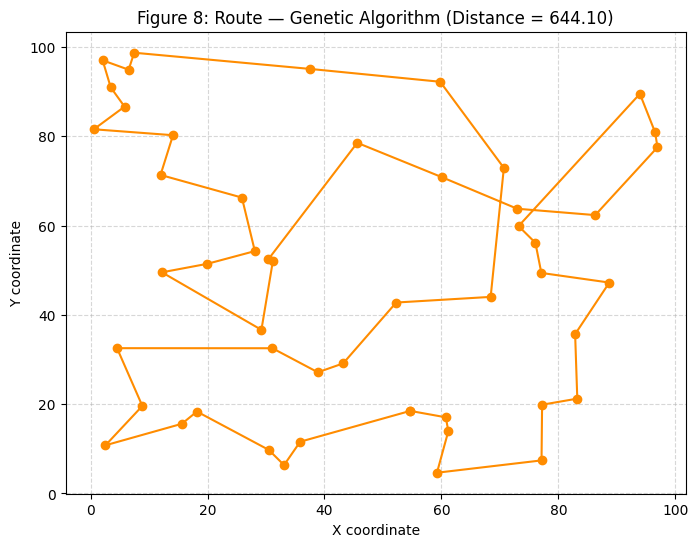

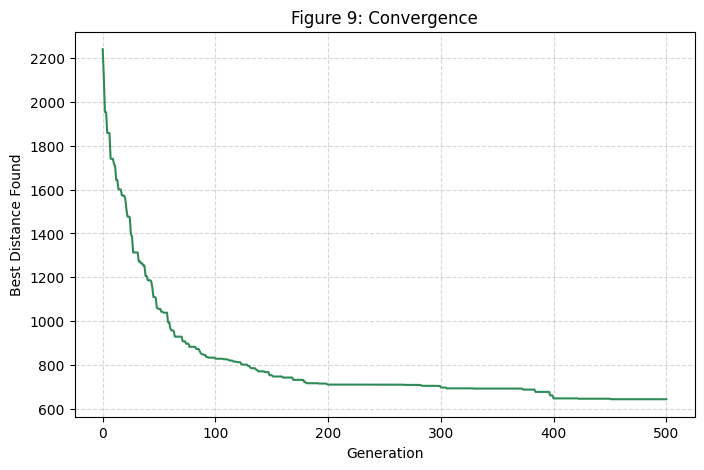

In [32]:
plot_route(ga_best_route, coords, title=f"Figure 8: Route — Genetic Algorithm (Distance = {ga_best_dist:.2f})")

plt.figure(figsize=(8, 5))
plt.plot(ga_history, color='seagreen')
plt.title("Figure 9: Convergence")
plt.xlabel("Generation")
plt.ylabel("Best Distance Found")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Saving the GA Best Route

The best route found by the Genetic Algorithm is saved to an external file for record-keeping and reproducibility.

In [33]:
save_route_to_file(ga_best_route, cities_df, 'genetic_algorithm_best_route.txt')
print("Route saved to genetic_algorithm_best_route.txt")

with open('genetic_algorithm_best_route.txt') as f:
    print(f.read())

Route saved to genetic_algorithm_best_route.txt
City_25
City_40
City_42
City_19
City_8
City_3
City_50
City_29
City_30
City_43
City_31
City_10
City_49
City_20
City_38
City_28
City_1
City_35
City_17
City_6
City_22
City_4
City_37
City_34
City_46
City_23
City_33
City_14
City_21
City_12
City_24
City_9
City_13
City_5
City_44
City_41
City_26
City_18
City_27
City_2
City_47
City_48
City_45
City_32
City_7
City_36
City_39
City_15
City_11
City_16
City_25



## Scalability Testing

To look at how each algorithm scales, I'll run both Hill Climbing and the Genetic Algorithm on subsets of the city data at sizes 10, 20, 30, 40, and 50 cities. For each size, the best distance found and the computation time are recorded, enabling comparison of solution quality and efficiency as problem size increases.

In [34]:
def run_scalability_test(cities_df, sizes, n_reps=5):
    """Run both tuned algorithms n_reps times per problem size."""
    results = []
    for size in sizes:
        subset = cities_df.iloc[:size]
        subset_coords = list(zip(subset['X'], subset['Y']))
        for rep in range(n_reps):
            set_seed(SEED + rep)
            start = time.time()
            _, hc_dist, _ = hill_climb_2opt(subset_coords,
                                            max_iterations=HC_MAX_ITERATIONS,
                                            stall_limit=HC_STALL_LIMIT_TUNED)
            results.append({'Size': size, 'Algorithm': 'Hill Climbing', 'Rep': rep,
                            'Distance': hc_dist, 'Time': time.time() - start})
            set_seed(SEED + rep)
            start = time.time()
            _, ga_dist, _ = genetic_algorithm(subset_coords,
                                              pop_size=GA_POP_SIZE_TUNED,
                                              generations=GA_GENERATIONS,
                                              mutation_rate=GA_MUTATION_RATE_TUNED,
                                              tournament_k=GA_TOURNAMENT_K)
            results.append({'Size': size, 'Algorithm': 'Genetic Algorithm', 'Rep': rep,
                            'Distance': ga_dist, 'Time': time.time() - start})
        print(f"Size {size} done ({n_reps} runs per algorithm)")
    return pd.DataFrame(results)


scalability_results = run_scalability_test(cities_df, [10, 20, 30, 40, 50])
scalability_results.to_csv('scalability_results.csv', index=False)
print(scalability_results.groupby(['Size', 'Algorithm'])[['Distance', 'Time']]
      .agg(['mean', 'std']).round(2))

Size 10 done (5 runs per algorithm)
Size 20 done (5 runs per algorithm)
Size 30 done (5 runs per algorithm)
Size 40 done (5 runs per algorithm)
Size 50 done (5 runs per algorithm)
                       Distance          Time      
                           mean    std   mean   std
Size Algorithm                                     
10   Genetic Algorithm   290.31   0.00   3.70  0.73
     Hill Climbing       290.31   0.00   0.46  0.14
20   Genetic Algorithm   411.70  23.43   6.01  0.57
     Hill Climbing       386.43   0.00   0.89  0.24
30   Genetic Algorithm   497.20  18.19   8.55  0.78
     Hill Climbing       455.34   4.89   1.32  0.39
40   Genetic Algorithm   576.80  39.36  11.94  0.21
     Hill Climbing       493.50   3.08   1.52  0.20
50   Genetic Algorithm   676.45  54.38  15.35  0.35
     Hill Climbing       592.81  14.18   2.06  0.52


## Scalability Results Visualisation

Figure 10 compares solution quality and figure 11 shows computation time across problem sizes of 10-50 cities. It shows the GA is working correctly.

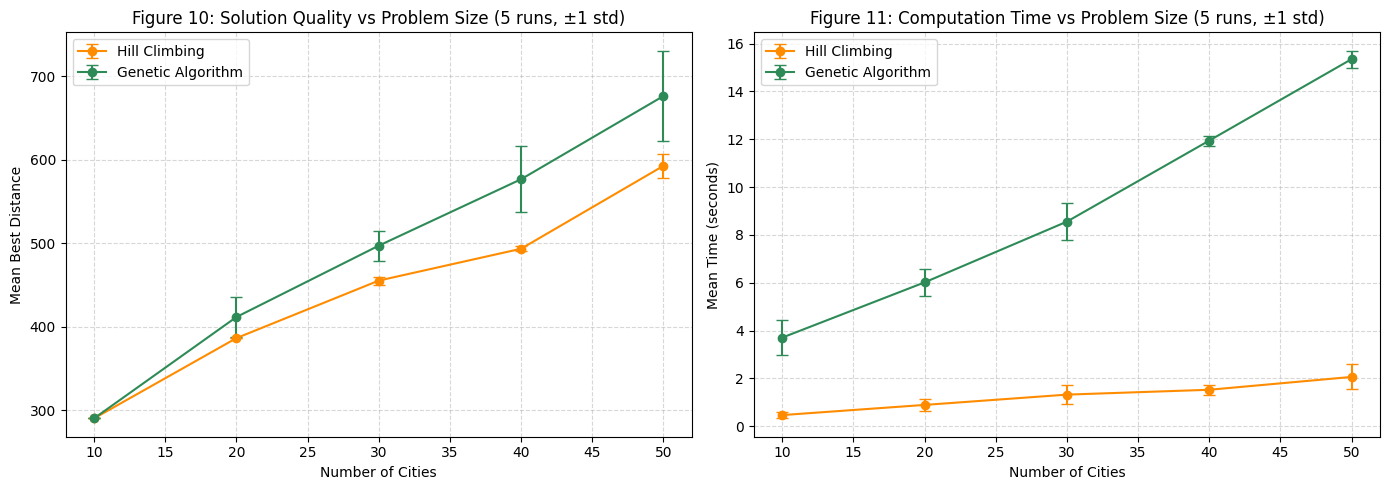

In [35]:
plot_data = scalability_results.groupby(['Size', 'Algorithm'])[['Distance', 'Time']] \
    .agg(['mean', 'std']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colours = {'Hill Climbing': 'darkorange', 'Genetic Algorithm': 'seagreen'}
for alg in colours:
    sub = plot_data[plot_data['Algorithm'] == alg]
    axes[0].errorbar(sub['Size'], sub[('Distance', 'mean')], yerr=sub[('Distance', 'std')],
                     fmt='o-', capsize=4, color=colours[alg], label=alg)
    axes[1].errorbar(sub['Size'], sub[('Time', 'mean')], yerr=sub[('Time', 'std')],
                     fmt='o-', capsize=4, color=colours[alg], label=alg)
axes[0].set_title("Figure 10: Solution Quality vs Problem Size (5 runs, ±1 std)")
axes[0].set_xlabel("Number of Cities"); axes[0].set_ylabel("Mean Best Distance")
axes[1].set_title("Figure 11: Computation Time vs Problem Size (5 runs, ±1 std)")
axes[1].set_xlabel("Number of Cities"); axes[1].set_ylabel("Mean Time (seconds)")
for ax in axes:
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('scalability_comparison.png', dpi=150)
plt.show()

### Statistical Significance Testing

The scalability should basically suggest that hill climbing finds shorter routes than the genetic algroithm. A difference in means could arise from random variation. To test if the observed difference is statistically significant, both algoriths are run 10 times independently on the full 50-city instance and the resulting distributions of best distances compared here.

In [36]:
from scipy import stats

N_RUNS = 10


def repeated_runs(algorithm_func, coords, n_runs=N_RUNS, **kwargs):
    """
    Run an algorithm multiple times with distinct seeds and collect results.

    Each run is seeded with SEED + run index so the experiment is fully
    reproducible while still sampling independent stochastic trajectories.

    Args:
        algorithm_func (callable): The algorithm function to run.
        coords (list): List of (x, y) tuples for each city.
        n_runs (int): Number of independent runs.
        **kwargs: Additional arguments passed to the algorithm function.

    Returns:
        list: Best distance found in each run.
    """
    distances = []
    for run in range(n_runs):
        set_seed(SEED + run)
        _, dist, _ = algorithm_func(coords, **kwargs)
        distances.append(dist)
    return distances


hc_runs = repeated_runs(
    hill_climb_2opt, coords,
    max_iterations=HC_MAX_ITERATIONS,
    stall_limit=HC_STALL_LIMIT_TUNED
)
ga_runs = repeated_runs(
    genetic_algorithm, coords,
    pop_size=GA_POP_SIZE_TUNED,
    generations=GA_GENERATIONS,
    mutation_rate=GA_MUTATION_RATE_TUNED,
    tournament_k=GA_TOURNAMENT_K
)

print(f"Hill Climbing  — mean: {np.mean(hc_runs):.2f}, "
      f"std: {np.std(hc_runs, ddof=1):.2f}, best: {min(hc_runs):.2f}")
print(f"Genetic Alg.   — mean: {np.mean(ga_runs):.2f}, "
      f"std: {np.std(ga_runs, ddof=1):.2f}, best: {min(ga_runs):.2f}")

# Welch's t-test: independent samples, unequal variances not assumed equal.
t_stat, p_welch = stats.ttest_ind(hc_runs, ga_runs, equal_var=False)
print(f"\nWelch's t-test:  t = {t_stat:.4f}, p = {p_welch:.6f}")

# Mann-Whitney U: non-parametric check, no normality assumption.
u_stat, p_mwu = stats.mannwhitneyu(hc_runs, ga_runs, alternative='two-sided')
print(f"Mann-Whitney U:  U = {u_stat:.1f}, p = {p_mwu:.6f}")

if p_welch < 0.05:
    print("\nThe null hypothesis is rejected at alpha = 0.05: there is a "
          "statistically significant difference in mean solution quality.")
else:
    print("\nThe null hypothesis is not rejected at alpha = 0.05.")

Hill Climbing  — mean: 589.65, std: 12.91, best: 573.06
Genetic Alg.   — mean: 700.78, std: 57.15, best: 598.83

Welch's t-test:  t = -5.9974, p = 0.000137
Mann-Whitney U:  U = 3.0, p = 0.000440

The null hypothesis is rejected at alpha = 0.05: there is a statistically significant difference in mean solution quality.


## Conclusions

### What I found

Over 10 seeded runs on the 50-city instance, my Hill Climber found shorter routes than the GA (mean 589.65 vs 700.78). Both the Welch t-test (p = 0.000137) and Mann-Whitney U (p = 0.000440) say that difference is real and not just noise. I used two tests because with only 10 runs I can't really check whether the data is normal, so I wanted a result that didn't depend on assuming it was.

The gap is bigger than the means make it look. My GA ran a population of 200 for 500 generations, so roughly 100,000 fitness evaluations. The Hill Climber
only got 20,000. It won by about 16% while doing a fifth of the work, and it was around ten times faster at every problem size I tested.

It was also far more consistent. Hill Climbing's standard deviation was 12.91 against the GA's 57.15, so it isn't just better on average, it's more reliable run to run. That matters if you only get one run.

### Why I think Hill Climbing won

It comes down to the operators, not the algorithms themselves. 2-opt reverses a segment, which directly rips out crossing edges, and crossing edges are exactly what makes a Euclidean tour bad. My GA's only local refinement is swap
mutation, which shuffles cities around without any idea of the tour's geometry, and Order Crossover mixes up parent orderings without protecting the edges that actually decide tour length. So the GA explores well but exploits badly.

Two things back this up. At 10 cities both algorithms hit exactly 290.31 with zero variance, which is almost certainly the optimum, so the GA clearly isn't broken. The gap only opens up as the instance gets bigger. And the GA's best
single run (598.83) is about the same as Hill Climbing's average, so it can find good tours, it just can't do it consistently.

### What I'd recommend

For Euclidean TSP at this size, on a tight time budget, or where you need consistent results, I'd deploy the Hill Climber with a 2-opt neighbourhood. It's faster, better, more reliable, and there's only one hyperparameter to tune.

I wouldn't write the GA off though. Its population keeps diversity that a single-solution search can't, which earns its place on rugged landscapes, on problems where there's no strong local move like 2-opt available, and on multi-objective versions where you actually want a spread of solutions. The population is also easy to parallelise, which would claw back some of the time cost.

### Limitations

I didn't match the budgets, and the GA got the bigger one, so if anything this result flatters the Hill Climber less than it could.

The obvious next step is a memetic algorithm — run 2-opt on the GA's offspring. That would give the population the exploitation it's missing, and it would tell me whether the GA's problem is really the population-based approach or just its weak local operators. I'd expect it to beat both.